In [1]:
%load_ext autoreload
%autoreload 2

In [13]:
import corc.graph_metrics.neb
import corc.utils
import corc.our_datasets
import os
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import tqdm

cache_path="../../cache"

In [3]:
datasets = corc.our_datasets.CORE_HD_DATASETS
dataset = datasets[0]
print(dataset)

densired8


In [4]:
X, y, tsne = corc.utils.load_dataset(dataset, cache_path=cache_path)

In [5]:
tmms = corc.utils.load_tmms(dataset, cache_path=cache_path)

In [8]:
levels, assignments = tmms[0].get_thresholds_and_cluster_numbers()

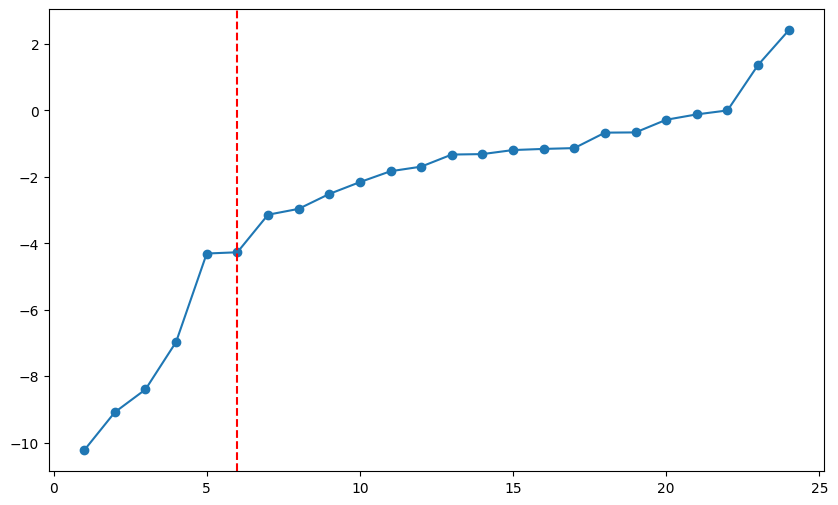

In [ ]:

tmms = corc.utils.load_tmms(dataset, cache_path=cache_path)
X, y, tsne = corc.utils.load_dataset(dataset, cache_path=cache_path)
levels, assignments = tmms[0].get_thresholds_and_cluster_numbers()
keys = list(levels.keys())
values = list(levels.values())
# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(keys, values, marker='o')
plt.axvline(x=len(np.unique(y)), color='r', linestyle='--', label='Position 6')


12it [00:02,  4.86it/s]


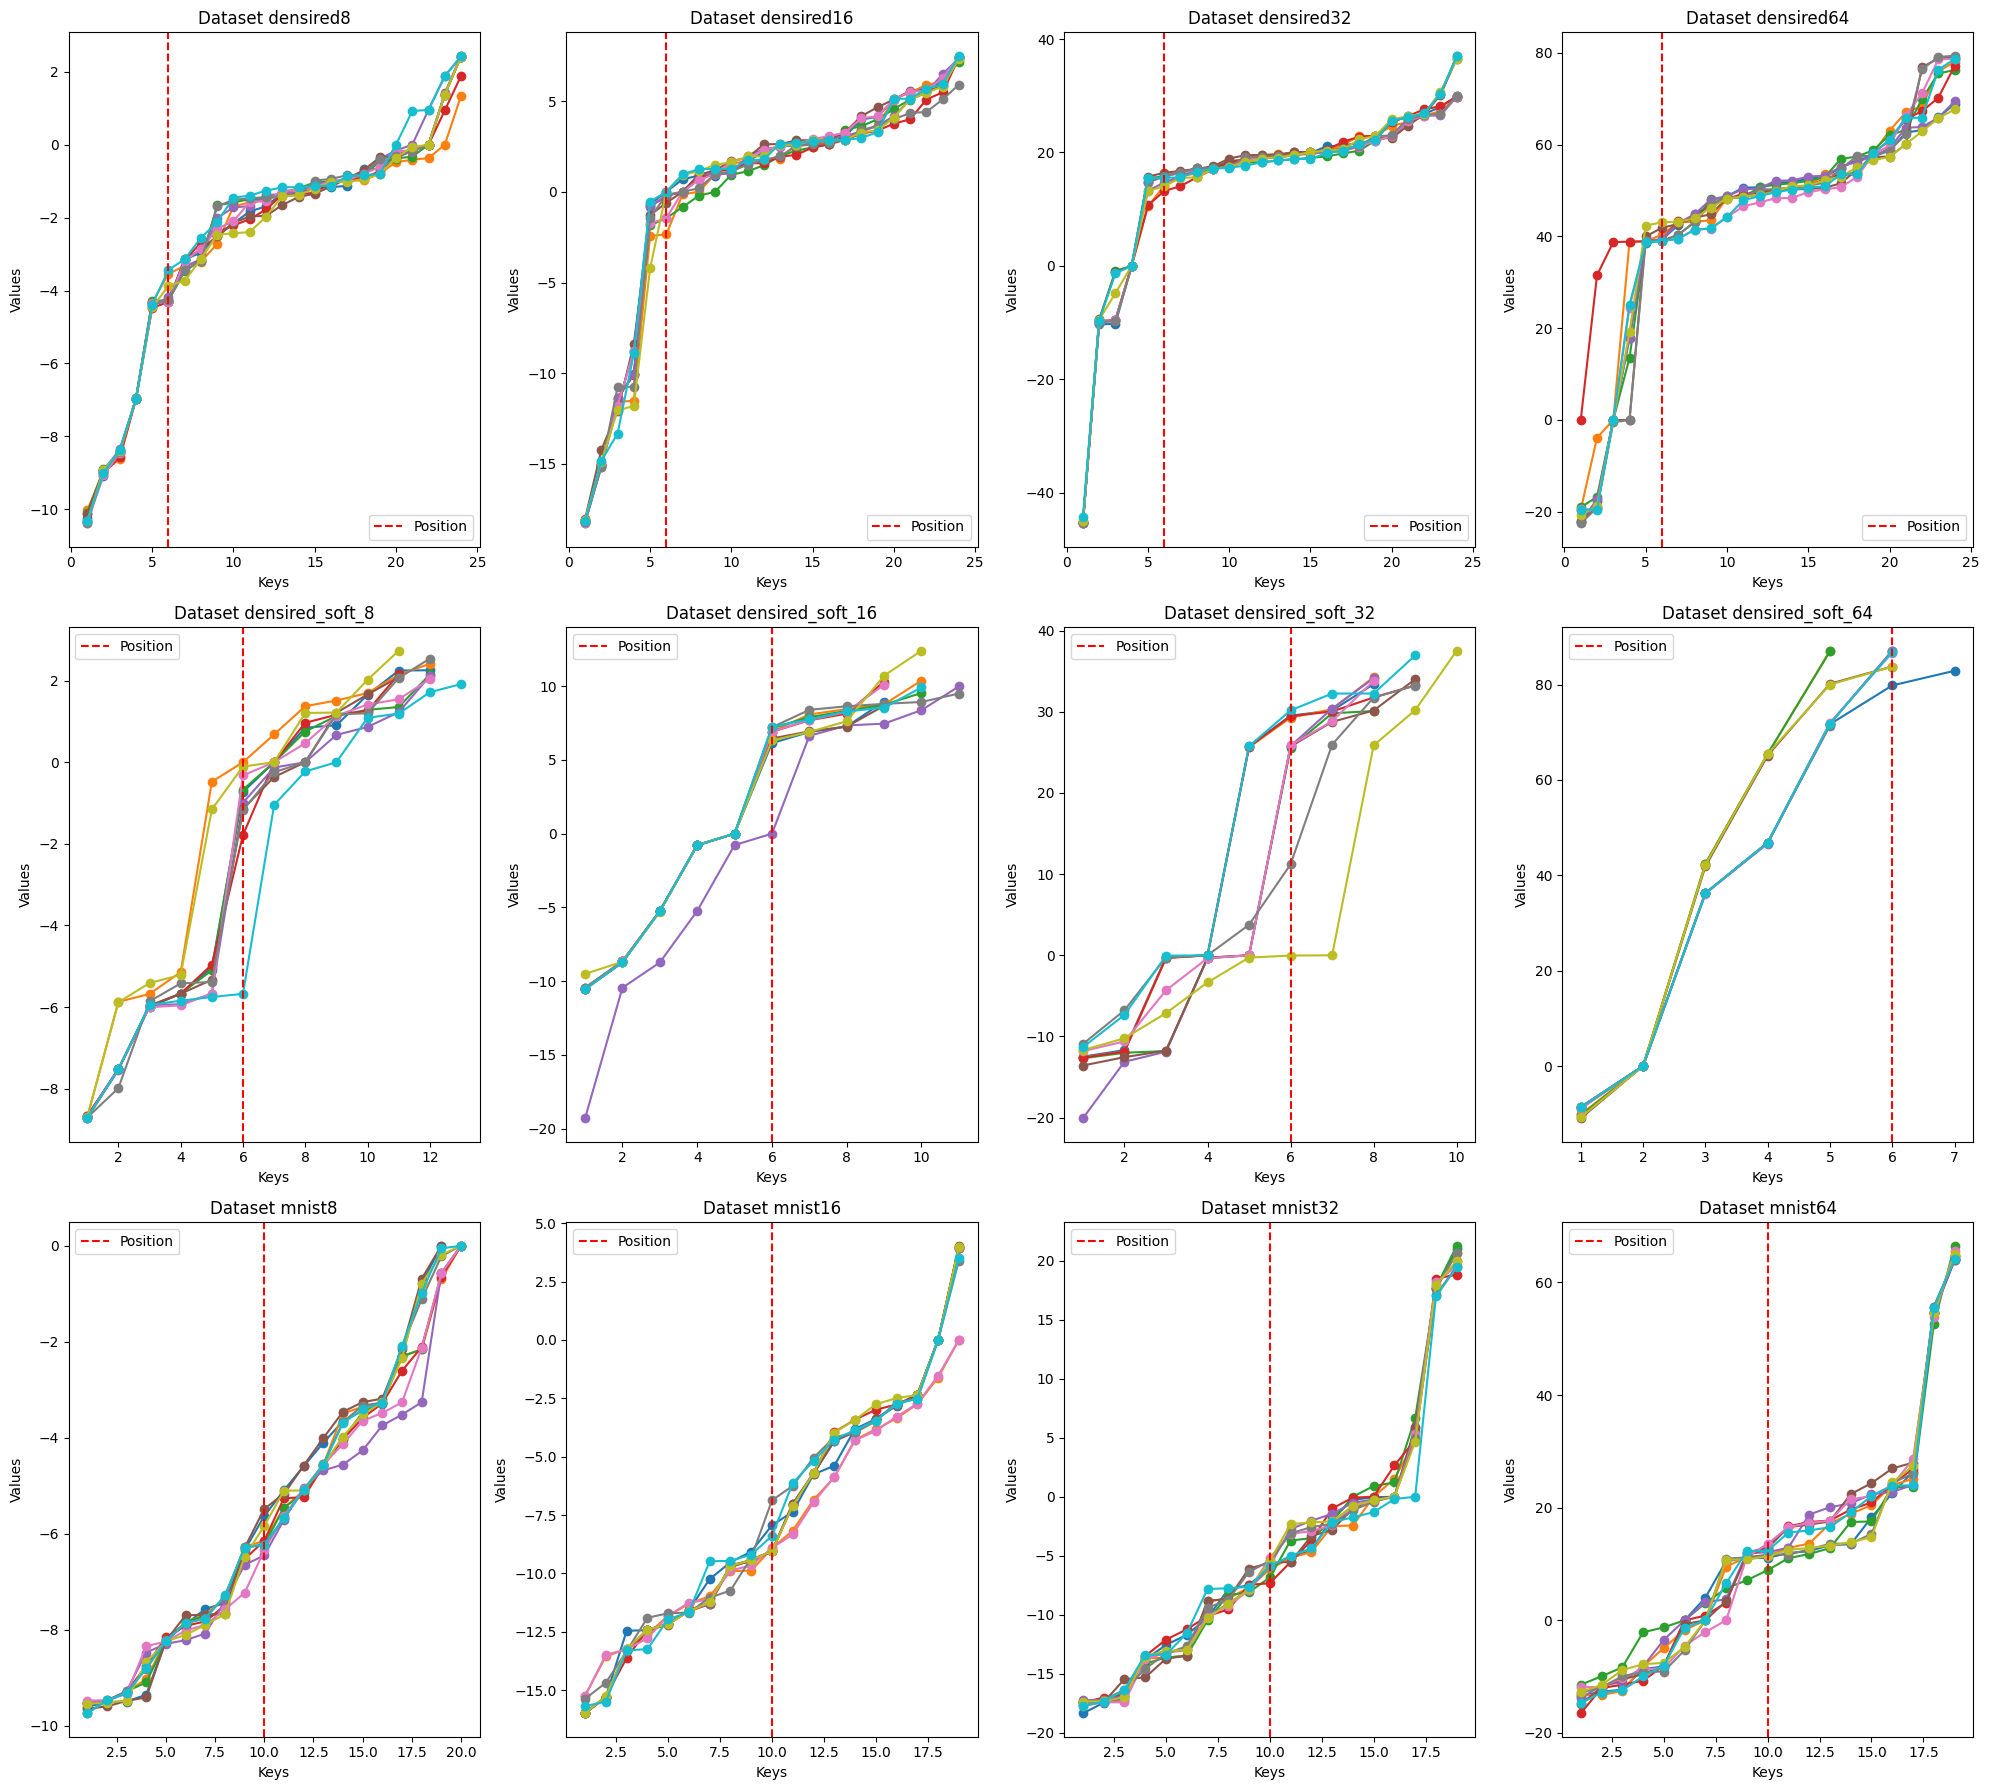

In [ ]:
# Calculate the number of rows needed
n_rows = (len(datasets) + 3) // 4  # equivalent to math.ceil(len(datasets) / 4)

# Create the subplots
fig, axs = plt.subplots(n_rows, 4, figsize=(20, n_rows * 6))

cache_path = "../../cache2"
# Loop over the datasets and plot
for i, dataset in tqdm.tqdm(enumerate(datasets)):
    row = i // 4
    col = i % 4
    
    tmms = corc.utils.load_tmms(dataset, cache_path=cache_path)
    for tmm in tmms:
        levels, assignments = tmm.get_thresholds_and_cluster_numbers()
        X, y, tsne = corc.utils.load_dataset(dataset, cache_path=cache_path)
        keys = list(levels.keys())
        values = list(levels.values())
        axs[row, col].plot(keys, values, marker='o')
        
    axs[row, col].axvline(x=len(np.unique(y)), color='r', linestyle='--', label='Position')
    axs[row, col].set_title(f'Dataset {dataset}')
    axs[row, col].set_xlabel('Keys')
    axs[row, col].set_ylabel('Values')
    axs[row, col].legend()

# Hide any unused subplots
for i in range(len(datasets), n_rows * 4):
    row = i // 4
    col = i % 4
    axs[row, col].axis('off')

plt.tight_layout()
plt.show()